In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:

data="/home/richard/Downloads/New Wave/mali/customer-churn.csv"
dataFrame = pd.read_csv(data)

In [4]:

dataFrame = pd.read_csv(data)

In [5]:
dataFrame.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [6]:
#change name 
dataFrame.columns = dataFrame.columns.str.lower().str.replace(' ','_')

categoricalColumns = list(dataFrame.dtypes[dataFrame.dtypes == 'object'].index)

for c in categoricalColumns:
    dataFrame[c] = dataFrame[c].str.lower().str.replace(' ', '_')

In [7]:
dataFrame.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [8]:
#convert all non floating point values to floating points in numerical columns
tc = pd.to_numeric(dataFrame.totalcharges, errors='coerce')

In [9]:
dataFrame.totalcharges =  pd.to_numeric(dataFrame.totalcharges, errors='coerce')

In [10]:
dataFrame.totalcharges = dataFrame.totalcharges.fillna(0)

In [11]:
dataFrame.churn

0        no
1        no
2       yes
3        no
4       yes
       ... 
7038     no
7039     no
7040     no
7041    yes
7042     no
Name: churn, Length: 7043, dtype: object

In [12]:
dataFrame.churn = (dataFrame.churn == 'yes').astype(int)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
dataFrameFullTrain, dataFrameTest = train_test_split(dataFrame,test_size=0.2,random_state=1)
dataFrameTrain, dataFrameValidate = train_test_split(dataFrameFullTrain,test_size=0.2,random_state=1)
dataFrameTrain.reset_index(drop=True)
dataFrameTest.reset_index(drop=True)
dataFrameValidate.reset_index(drop=True)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5846-neqvz,male,0,yes,yes,71,yes,no,dsl,yes,...,yes,yes,no,yes,two_year,yes,credit_card_(automatic),70.85,4973.40,0
1,3645-deygf,male,0,no,yes,1,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,mailed_check,20.75,20.75,0
2,3590-tcxtb,male,0,no,no,1,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,mailed_check,20.35,20.35,0
3,8433-wxgna,male,0,no,no,2,yes,no,fiber_optic,yes,...,no,no,no,no,month-to-month,yes,electronic_check,75.70,189.20,1
4,2654-vbvpb,female,0,no,no,1,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,bank_transfer_(automatic),19.90,19.90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,0902-xkxpn,male,0,yes,yes,69,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,bank_transfer_(automatic),20.20,1376.50,0
1123,6227-fbdxh,male,0,yes,no,69,yes,yes,fiber_optic,no,...,yes,no,yes,yes,one_year,no,bank_transfer_(automatic),99.50,6841.45,0
1124,9313-cdogy,male,0,yes,yes,38,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,month-to-month,no,electronic_check,19.60,717.30,0
1125,2528-hfyzx,male,1,yes,no,17,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,76.45,1233.40,1


In [15]:
yTrain = dataFrameTrain.churn.values
yValidate = dataFrameValidate.churn.values
yTest = dataFrameTest.churn.values

In [16]:
del dataFrameTest['churn']
del dataFrameValidate['churn']
del dataFrameTrain['churn']

In [17]:
len(dataFrameFullTrain), len(dataFrameTest)

(5634, 1409)

In [18]:
dataFrameFullTrain.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [19]:
dataFrameFullTrain.churn

1814    0
5946    1
3881    0
2389    0
3676    0
       ..
905     1
5192    0
3980    1
235     1
5157    0
Name: churn, Length: 5634, dtype: int64

In [20]:
categorialColumns = [
"gender",        
"seniorcitizen", 
"partner",       
"dependents",    
"phoneservice",  
"multiplelines", 
"internetservice",
"onlinesecurity",
"onlinebackup",  
"deviceprotection",   
"techsupport",   
"streamingtv",   
"streamingmovies",
"contract",      
"paperlessbilling",   
"paymentmethod",
"churn"]

In [21]:
dataFrameFullTrain[categorialColumns].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
churn               2
dtype: int64

In [22]:
femaleChurnRate = dataFrameFullTrain[dataFrameFullTrain.gender == 'female'].churn.mean()
femaleChurnRate

np.float64(0.27682403433476394)

In [23]:

maleChurnRate = dataFrameFullTrain[dataFrameFullTrain.gender == 'male'].churn.mean()
maleChurnRate

np.float64(0.2632135306553911)

In [24]:
globalChurn = dataFrameFullTrain.churn.mean()
globalChurn

np.float64(0.26996805111821087)

In [ ]:
npositiveChurnPartner = dataFrameFullTrain[dataFrameFullTrain.partner == 'yes'].churn.mean()
positiveChurnPartner

np.float64(0.20503330866025166)

In [26]:

globalChurn = dataFrameFullTrain.churn.mean()
globalChurn - positiveChurnPartner

np.float64(0.06493474245795922)

In [27]:

negativeChurnPartner = dataFrameFullTrain[dataFrameFullTrain.partner == 'no'].churn.mean()
negativeChurnPartner

np.float64(0.3298090040927694)

In [28]:
negativeChurnPartner/globalChurn

np.float64(1.2216593879412643)

In [29]:
for c in categorialColumns:
    print(c)
    dataFrameGroup = dataFrameFullTrain.groupby(c).churn.agg(['mean','count'])
    dataFrameGroup['diff'] = dataFrameGroup['mean'] - globalChurn
    dataFrameGroup['risk'] = dataFrameGroup['mean'] / globalChurn
    display(dataFrameGroup)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121




churn


,mean,count,diff,risk
churn,,,,
0,0.0,4113,-0.269968,0.000000
1,1.0,1521,0.730032,3.704142


In [30]:
from sklearn.metrics import mutual_info_score

In [31]:
mutual_info_score(dataFrameFullTrain.contract, dataFrameFullTrain.churn)

np.float64(0.0983203874041556)

In [32]:

mutual_info_score(dataFrameFullTrain.gender, dataFrameFullTrain.churn)

np.float64(0.0001174846211139946)

In [33]:
mutual_info_score(dataFrameFullTrain.partner, dataFrameFullTrain.churn)

np.float64(0.009967689095399745)

In [34]:
def mutual_info_churn_score(series):
    return mutual_info_churn_score(series,dataFrameFullTrain.churn)

In [35]:
mi = dataFrameFullTrain[categoricalColumns].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

TypeError: mutual_info_churn_score() takes 1 positional argument but 2 were given

In [38]:
#One-hot encoding
from sklearn.feature_extraction import DictVectorizer

In [ ]:
trainDictionary = dataFrameTrain[[categoricalColumns]].to_dict(orient='records')

KeyError: "None of [Index([('customerid', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'totalcharges', 'churn')], dtype='object')] are in the [columns]"

In [44]:
dv = DictVectorizer()

In [43]:
dv.fit(dicts)

NameError: name 'dicts' is not defined

In [42]:
#get feature name out
dv.get_feature_names_out()

NotFittedError: This DictVectorizer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [41]:
newsp = dv.transform(dicts)


NameError: name 'dicts' is not defined

In [45]:
#logistic regression
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [ ]:

z = np.linspace(-7,5,51)
z

array([-5. , -4.8, -4.6, -4.4, -4.2, -4. , -3.8, -3.6, -3.4, -3.2, -3. ,
       -2.8, -2.6, -2.4, -2.2, -2. , -1.8, -1.6, -1.4, -1.2, -1. , -0.8,
       -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,
        1.6,  1.8,  2. ,  2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,
        3.8,  4. ,  4.2,  4.4,  4.6,  4.8,  5. ])

In [47]:
sigmoid(z)

array([0.00669285, 0.00816257, 0.0099518 , 0.01212843, 0.01477403,
       0.01798621, 0.02188127, 0.02659699, 0.03229546, 0.03916572,
       0.04742587, 0.05732418, 0.06913842, 0.0831727 , 0.09975049,
       0.11920292, 0.14185106, 0.16798161, 0.19781611, 0.23147522,
       0.26894142, 0.31002552, 0.35434369, 0.40131234, 0.450166  ,
       0.5       , 0.549834  , 0.59868766, 0.64565631, 0.68997448,
       0.73105858, 0.76852478, 0.80218389, 0.83201839, 0.85814894,
       0.88079708, 0.90024951, 0.9168273 , 0.93086158, 0.94267582,
       0.95257413, 0.96083428, 0.96770454, 0.97340301, 0.97811873,
       0.98201379, 0.98522597, 0.98787157, 0.9900482 , 0.99183743,
       0.99330715])

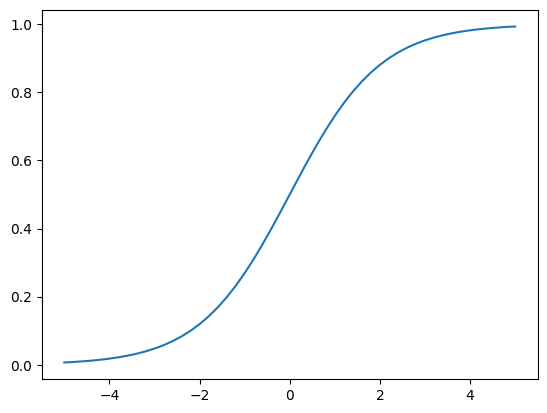

In [48]:
plt.plot(z,sigmoid(z))

In [ ]:
from sklearn.linear_model import LogisticRegression